In [3]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from swot import browse_swot_2km, add_mask_inside_swot, build_swath_polygon, coloc_swot, rotate_ggd

In [4]:
dfs = browse_swot_2km().reset_index()
dss = xr.open_dataset(dfs.file.iloc[0])

In [14]:
sla = dss.duacs_ssha_karin_2_filtered.isel(num_lines = slice(150, 200), num_pixels = slice(10, 30))

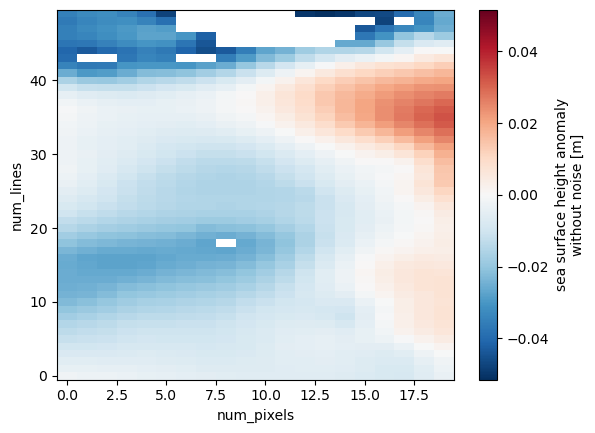

In [15]:
sla.plot()

# Fitting kernel filter inspired from Tranchant et al. 2025

- for 2D fitting : https://stackoverflow.com/questions/33964913/equivalent-of-polyfit-for-a-2d-polynomial-in-python
- for to apply : https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.generic_filter.html#scipy.ndimage.generic_filter

import numpy as np
from scipy import datasets
from scipy.ndimage import generic_filter
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

def fitting(image):
    if isinstance(image, xr.DataArray): image = image.values
    x = np.arange(image.shape[0])
    y = np.arange(image.shape[1])
    X, Y = np.meshgrid(x, y, copy=False)
    X = X.flatten()
    Y = Y.flatten()

    Z=image.flatten()

    # Process 2D inputs
    poly = PolynomialFeatures(degree=2)
    input_pts = np.stack([X, Y]).T
    assert(input_pts.shape == (image.shape[0]*image.shape[1], 2))
    in_features = poly.fit_transform(input_pts)
    
    # Linear regression
    model = LinearRegression(fit_intercept=False)
    print(Z)
    model.fit(in_features,Z)

    # Display coefficients
    print(dict(zip(poly.get_feature_names_out(), model.coef_.round(4))))

    Zm = model.predict(poly.transform(input_pts))

    fitted_image = np.reshape(Zm, image.shape)
    return fitted_image


In [16]:
import numpy as np
from scipy import datasets
from scipy.ndimage import generic_filter
import matplotlib.pyplot as plt

def fitting(image): 
    n=int(np.sqrt(image.shape[0]))
    if isinstance(image, xr.DataArray): image = image.values
    x = np.arange(n)
    y = np.arange(n)
    X, Y = np.meshgrid(x, y, copy=False)
    X, Y = np.meshgrid(x, y, copy=False)

    X = X.flatten()
    Y = Y.flatten()

    A = np.array([X*0+1, X, Y, X**2, X**2*Y, X**2*Y**2, Y**2, X*Y**2, X*Y]).T

    coeff, r, rank, s = np.linalg.lstsq(A, image)
    
    Zm = A.dot(coeff)
    fitted_image = np.reshape(Zm, (n,n))
    return fitted_image



In [17]:
def fitting_kernel(image):
    fitted_image = fitting(image)
    lx, ly = fitted_im.shape
    return float(fitted_image[lx//2, ly//2])

def apply_fitting_kernel_filter(image, npts):
    return generic_filter(image, fitting_kernel, [npts, npts])

-0.00613812244897959


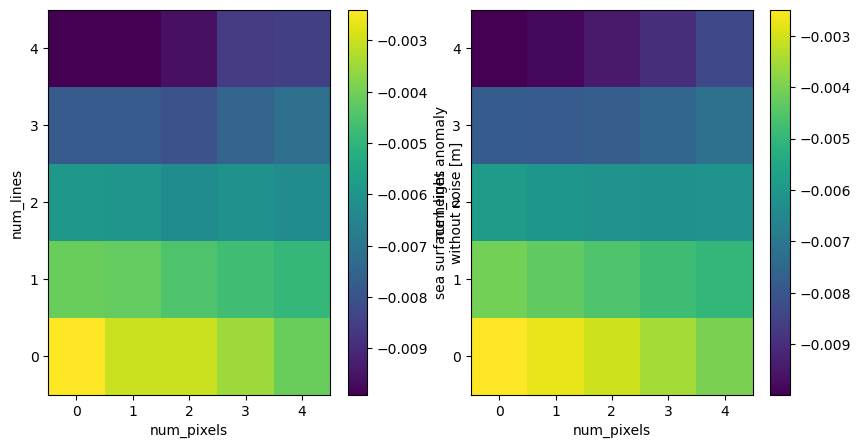

In [18]:
im_ = sla.isel(num_lines = slice(0,5), num_pixels = slice(0, 5))#.values
fitted_im = xr.DataArray(fitting(np.array(im_).flatten()), dims = im_.dims)
fig, axs =plt.subplots(1,2, figsize=(10, 5))
im_.plot(ax=axs[0])
fitted_im.plot(ax=axs[1])
print(fitting_kernel(np.array(im_).flatten()))

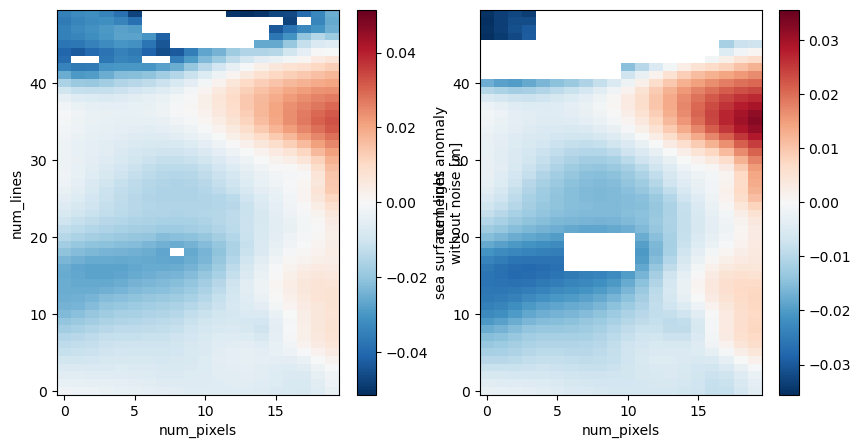

In [20]:
f = xr.DataArray(generic_filter(sla, fitting_kernel, size = [5,5]), dims=sla.dims)

fig, axs =plt.subplots(1,2, figsize=(10, 5))
sla.plot(ax=axs[0])
f.plot(ax=axs[1])

In [21]:
def fitting_coeff(image, ncoeff): 
    n=int(np.sqrt(image.shape[0]))
    if isinstance(image, xr.DataArray): image = image.values
    x = np.arange(n)
    y = np.arange(n)
    X, Y = np.meshgrid(x, y, copy=False)
    X, Y = np.meshgrid(x, y, copy=False)

    X = X.flatten()
    Y = Y.flatten()

    A = np.array([X*0+1, X, Y, X**2, X**2*Y, X**2*Y**2, Y**2, X*Y**2, X*Y]).T

    coeff, r, rank, s = np.linalg.lstsq(A, image)
    return coeff[ncoeff]

In [22]:
coef1 = xr.DataArray(generic_filter(sla, fitting_coeff, size = [5,5], extra_keywords = {'ncoeff':1}), dims=sla.dims)

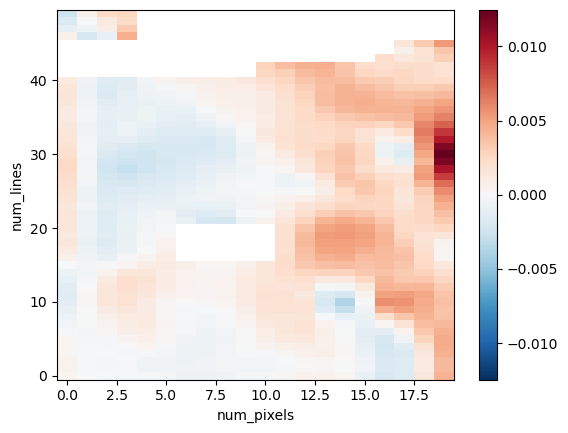

In [23]:
coef1.plot()

In [14]:
sla = dss.duacs_ssha_karin_2_filtered.isel(num_lines = slice(150, 200), num_pixels = slice(10, 30))

In [28]:
sla = dss.duacs_ssha_karin_2_filtered#.isel(num_lines = slice(150, 200), num_pixels = slice(10, 30))

coef1 = xr.DataArray(generic_filter(sla, fitting_coeff, size = [5,5], extra_keywords = {'ncoeff':1}), dims=sla.dims)

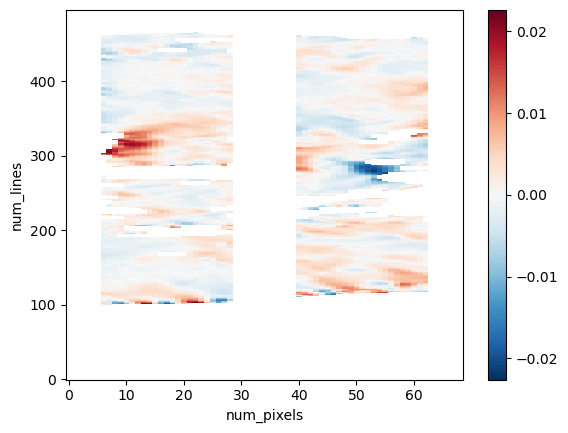

In [29]:
coef1.plot()